<a href="https://colab.research.google.com/github/Alisha-bhatti/DEEP-LEARNING-FOR-NATURAL-LANGUAGE-PROCESSING/blob/main/LSTM_Sentiment_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q tensorflow scikit-learn

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
# Load IMDB Dataset
max_words = 20000  # vocabulary size limit
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_words)
word_index = keras.datasets.imdb.get_word_index()
index_to_word = {value+3: key for key, value in word_index.items()}
index_to_word[0] = "<PAD>"
index_to_word[1] = "<START>"
index_to_word[2] = "<UNK>"
index_to_word[3] = "<UNUSED>"


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
def decode_review(sequence):
    return " ".join([index_to_word.get(i, "?") for i in sequence])
x_train_text = [decode_review(seq) for seq in x_train]
x_test_text = [decode_review(seq) for seq in x_test]


In [5]:
# 1: TF-IDF Feature Extraction
vectorizer = TfidfVectorizer(max_features=20000)
X_train_tfidf = vectorizer.fit_transform(x_train_text)
X_test_tfidf = vectorizer.transform(x_test_text)


In [6]:
# 2: Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

# 3: Evaluate Baseline
y_pred_lr = lr_model.predict(X_test_tfidf)
print("Baseline Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nBaseline Classification Report:\n")
print(classification_report(y_test, y_pred_lr))


Baseline Accuracy: 0.88432

Baseline Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.88      0.88     12500
           1       0.88      0.89      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



In [7]:
# 4— LSTM MODEL

# Step 1: Pad Sequences
max_len = 200
x_train_pad = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=max_len)
x_test_pad = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=max_len)

# Step 2: Build LSTM Model
model = keras.Sequential([
    layers.Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    layers.LSTM(64),
    layers.Dense(1, activation='sigmoid')
])

# Step 3: Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Step 4: Train Model
history = model.fit(
    x_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# Step 5: Evaluate LSTM
y_pred_lstm = (model.predict(x_test_pad) > 0.5).astype("int32")

print("LSTM Accuracy:", accuracy_score(y_test, y_pred_lstm))
print("\nLSTM Classification Report:\n")
print(classification_report(y_test, y_pred_lstm))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 96s 289ms/step - accuracy: 0.7779 - loss: 0.4527 - val_accuracy: 0.8712 - val_loss: 0.3196
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 259ms/step - accuracy: 0.9075 - loss: 0.2382 - val_accuracy: 0.8802 - val_loss: 0.2991
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 255ms/step - accuracy: 0.9479 - loss: 0.1442 - val_accuracy: 0.8400 - val_loss: 0.3829
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 87s 278ms/step - accuracy: 0.9711 - loss: 0.0847 - val_accuracy: 0.8672 - val_loss: 0.4178
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 260ms/step - accuracy: 0.9776 - loss: 0.0693 - val_accuracy: 0.8598 - val_loss: 0.4602
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step
LSTM Accuracy: 0.84996

LSTM Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.88      0.85     12500
           1       0.87      0.82      0.84     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85   

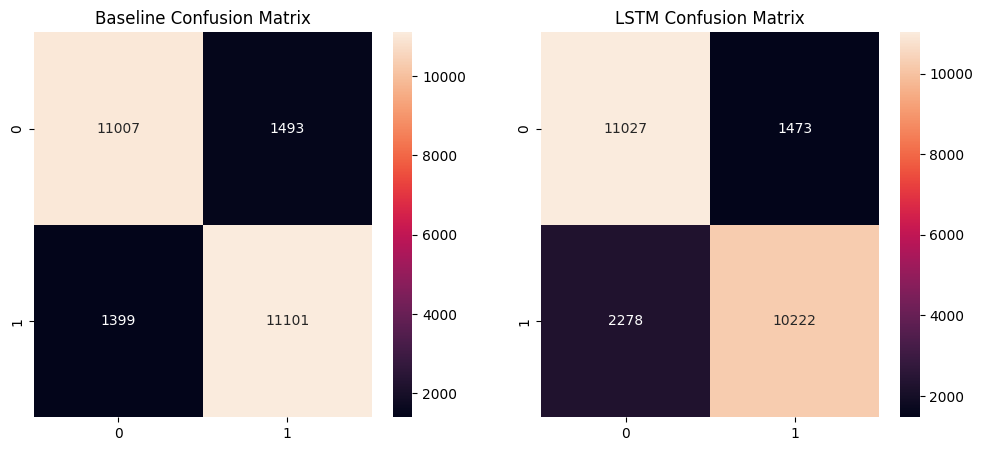

In [8]:
# PART 5 — Confusion Matrix Comparison

import seaborn as sns
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Baseline Confusion Matrix")

plt.subplot(1,2,2)
sns.heatmap(cm_lstm, annot=True, fmt='d')
plt.title("LSTM Confusion Matrix")

plt.show()
